In [3]:
from deepface import DeepFace
import os
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide tensorflow logs

In [5]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Virat Kohli.jpg"

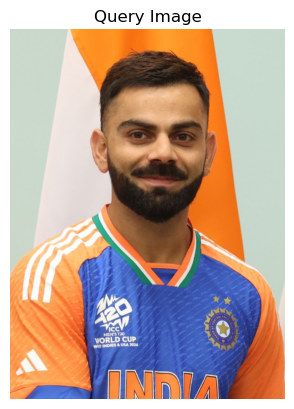

In [6]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [7]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="ArcFace",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-09 21:50:11 - Searching test_image/Virat Kohli.jpg in 38 length datastore
26-02-09 21:50:14 - find function duration 24.09505820274353 seconds


In [8]:
threshold = 0.35  # ArcFace threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Match found: Virat Kohli
Score: 0.913


In [9]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Stranger.jpg"

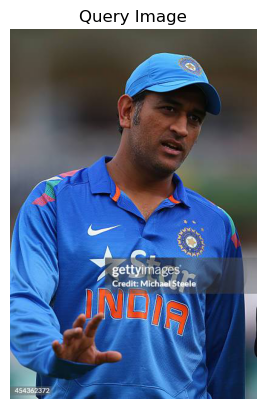

In [10]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [11]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="ArcFace",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-09 21:55:00 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 21:55:00 - find function duration 12.35116171836853 seconds


In [12]:
threshold = 0.35  # ArcFace threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Stranger detected


In [13]:
test_data = {}

for file in os.listdir("test_image"):
    if file.lower().endswith((".jpg", ".jpeg", ".png",".jpe")):
        name = os.path.splitext(file)[0]
        test_data[name] = f"test_image/{file}"

print(test_data)


{'Droupadi Murmu': 'test_image/Droupadi Murmu.jpg', 'Kiran Dutta': 'test_image/Kiran Dutta.png', 'PM Modi': 'test_image/PM Modi.jpg', 'Shreya Ghoshal': 'test_image/Shreya Ghoshal.jpg', 'Stranger': 'test_image/Stranger.jpg', 'Stranger1': 'test_image/Stranger1.jpg', 'Stranger2': 'test_image/Stranger2.jpg', 'Stranger3': 'test_image/Stranger3.jpg', 'Stranger4': 'test_image/Stranger4.jpg', 'Virat kohli': 'test_image/Virat kohli.jpg'}


In [14]:
correct = 0
total = 0
threshold = 0.35

known_people = set(os.listdir("database"))  

for label, img in test_data.items():

    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="Facenet",
        detector_backend="retinaface",
        enforce_detection=False
    )

    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]

        if distance < threshold:
            predicted = os.path.basename(os.path.dirname(best["identity"]))
        else:
            predicted = "stranger"

    print(f"True: {label} | Predicted: {predicted}")

    # normalize label
    true_label = label if label in known_people else "stranger"

    if predicted == true_label:
        correct += 1

    total += 1

accuracy = correct / total
print("\nAccuracy:", round(accuracy * 100, 2), "%")


26-02-09 21:55:27 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 21:55:33 - find function duration 22.259757041931152 seconds
True: Droupadi Murmu | Predicted: Droupadi Murmu
26-02-09 21:55:47 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 21:55:47 - find function duration 14.445013523101807 seconds
True: Kiran Dutta | Predicted: Kiran Dutta
26-02-09 21:56:01 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 21:56:01 - find function duration 13.957804918289185 seconds
True: PM Modi | Predicted: PM Modi
26-02-09 21:56:14 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 21:56:15 - find function duration 13.634739875793457 seconds
True: Shreya Ghoshal | Predicted: Shreya Ghoshal
26-02-09 21:56:28 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 21:56:28 - find function duration 12.999278545379639 seconds
True: Stranger | Predicted: stranger
26-02-09 21:56:39 - Searching test_ima

In [15]:
# FAR: stranger predicted as known
false_accept = 0
total_stranger = 0

for label, img in test_data.items():
    true_label = label if label in known_people else "stranger"
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="ArcFace",
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    if true_label == "stranger":
        total_stranger += 1
        if predicted != "stranger":
            false_accept += 1

far = false_accept / total_stranger if total_stranger > 0 else 0
print("False Acceptance Rate (FAR):", round(far * 100, 2), "%")


26-02-09 21:57:51 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 21:57:52 - find function duration 17.290130853652954 seconds
26-02-09 21:58:07 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 21:58:07 - find function duration 15.45572829246521 seconds
26-02-09 21:58:21 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 21:58:22 - find function duration 14.338519811630249 seconds
26-02-09 21:58:35 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 21:58:35 - find function duration 13.613244533538818 seconds
26-02-09 21:58:48 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 21:58:49 - find function duration 13.343921899795532 seconds
26-02-09 21:59:00 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-09 21:59:00 - find function duration 11.47354507446289 seconds
26-02-09 21:59:10 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-09 21:59:11 - find fu

In [17]:
# FRR: known person predicted as stranger
false_reject = 0
total_known = 0

for label, img in test_data.items():
    true_label = label if label in known_people else "stranger"
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="ArcFace",
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    if true_label != "stranger":
        total_known += 1
        if predicted == "stranger":
            false_reject += 1

frr = false_reject / total_known if total_known > 0 else 0
print("False Rejection Rate (FRR):", round(frr * 100, 2), "%")


26-02-09 22:04:25 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 22:04:26 - find function duration 15.453579664230347 seconds
26-02-09 22:04:39 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 22:04:40 - find function duration 13.821816682815552 seconds
26-02-09 22:04:52 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 22:04:52 - find function duration 12.37270474433899 seconds
26-02-09 22:05:04 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 22:05:05 - find function duration 12.603843450546265 seconds
26-02-09 22:05:16 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 22:05:17 - find function duration 12.16419267654419 seconds
26-02-09 22:05:27 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-09 22:05:27 - find function duration 10.748291015625 seconds
26-02-09 22:05:38 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-09 22:05:38 - find funct

26-02-09 22:08:45 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 22:08:45 - find function duration 16.276992321014404 seconds
26-02-09 22:08:59 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 22:08:59 - find function duration 13.788352012634277 seconds
26-02-09 22:09:11 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 22:09:12 - find function duration 12.569355487823486 seconds
26-02-09 22:09:25 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 22:09:25 - find function duration 13.092344284057617 seconds
26-02-09 22:09:37 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 22:09:37 - find function duration 12.405171871185303 seconds
26-02-09 22:09:48 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-09 22:09:49 - find function duration 11.662023305892944 seconds
26-02-09 22:10:00 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-09 22:10:01 - find 

<Figure size 1200x800 with 0 Axes>

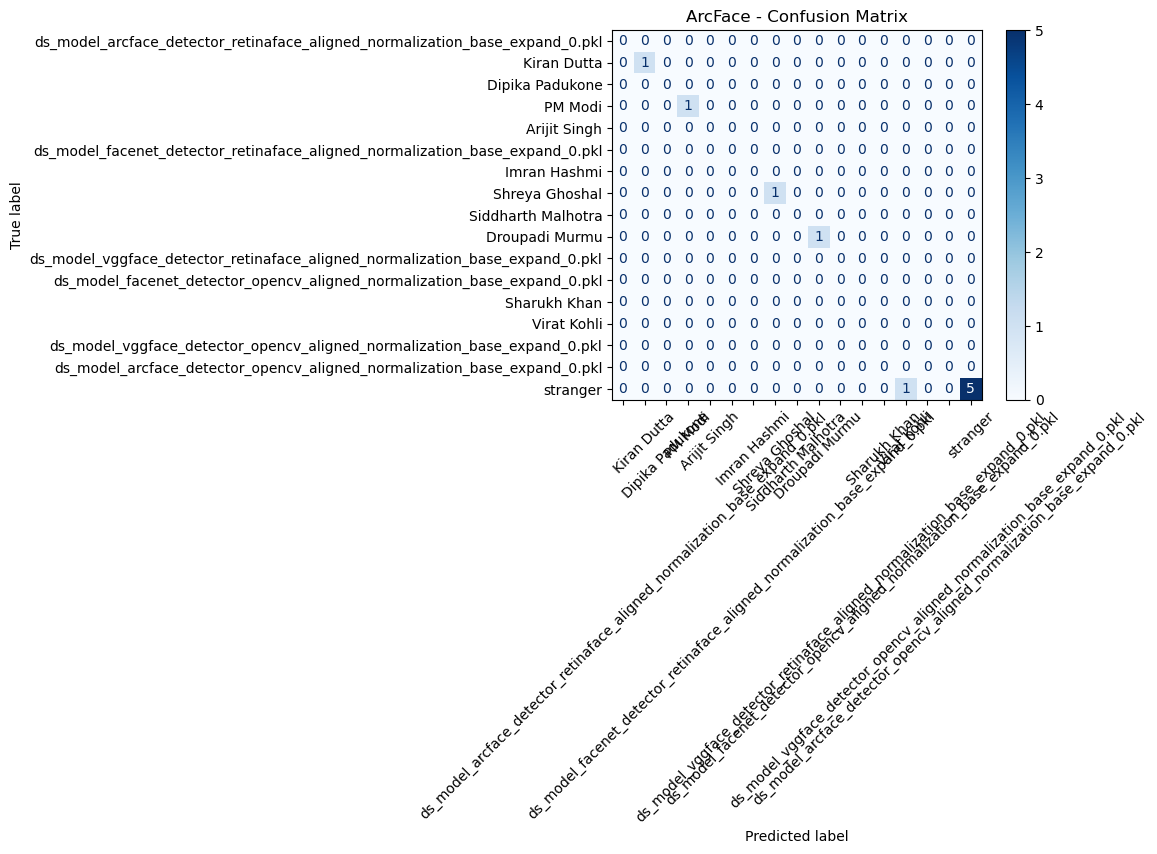

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_name = "ArcFace"
threshold = 0.35

y_true = []
y_pred = []

known_people = set(os.listdir("database"))

for label, img_path in test_data.items():
    results = DeepFace.find(
        img_path=img_path,
        db_path="database",
        model_name='ArcFace',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    true_label = label if label in known_people else "stranger"

    y_true.append(true_label)
    y_pred.append(predicted)

labels = list(known_people) + ["stranger"]
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(12,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title(f"{model_name} - Confusion Matrix")
plt.show()


26-02-09 22:11:55 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 22:11:56 - find function duration 15.543981552124023 seconds
26-02-09 22:12:09 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 22:12:09 - find function duration 13.688361883163452 seconds
26-02-09 22:12:21 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 22:12:22 - find function duration 12.302520036697388 seconds
26-02-09 22:12:34 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 22:12:34 - find function duration 12.604154825210571 seconds
26-02-09 22:12:47 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 22:12:47 - find function duration 12.534595727920532 seconds
26-02-09 22:12:58 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-09 22:12:58 - find function duration 11.015555620193481 seconds
26-02-09 22:13:09 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-09 22:13:09 - find 

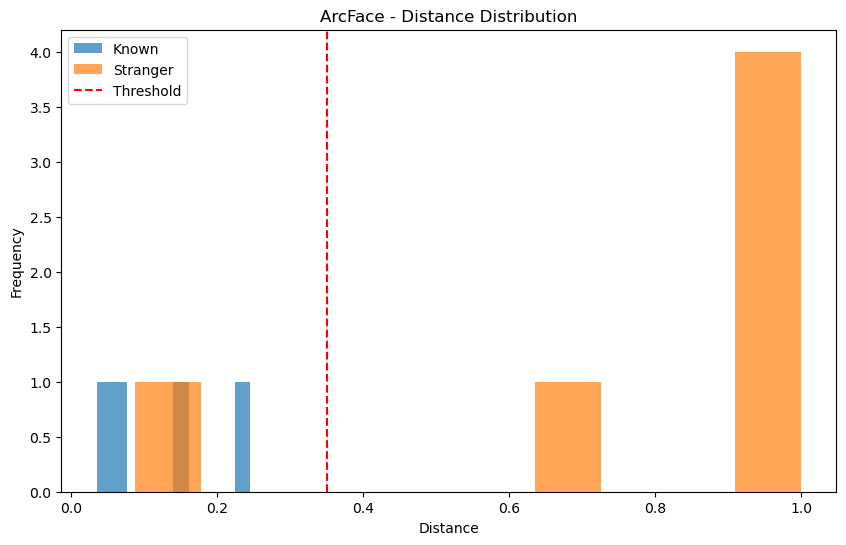

In [19]:
import matplotlib.pyplot as plt
import numpy as np

model_name = "ArcFace"
threshold = 0.35

known_distances = []
stranger_distances = []

for label, img in test_data.items():
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name='ArcFace',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        distance = 1.0  # large distance for stranger
    else:
        distance = df.iloc[0]["distance"]

    if label in os.listdir("database"):
        known_distances.append(distance)
    else:
        stranger_distances.append(distance)

plt.figure(figsize=(10,6))
plt.hist(known_distances, bins=10, alpha=0.7, label="Known")
plt.hist(stranger_distances, bins=10, alpha=0.7, label="Stranger")
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title(f"{model_name} - Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [24]:
from deepface import DeepFace
import time

test_images = {
    'Droupadi Murmu': 'test_image/Droupadi Murmu.jpg',
    'Kiran Dutta': 'test_image/Kiran Dutta.png',
    'PM Modi': 'test_image/PM Modi.jpg',
    'Shreya Ghoshal': 'test_image/Shreya Ghoshal.jpg',
    'Stranger': 'test_image/Stranger.jpg',
    'Stranger1': 'test_image/Stranger1.jpg',
    'Stranger2': 'test_image/Stranger2.jpg',
    'Stranger3': 'test_image/Stranger3.jpg',
    'Stranger4': 'test_image/Stranger4.jpg',
    'Virat kohli': 'test_image/Virat kohli.jpg'
}

db_path = "database"  # your database folder

inference_times = []

# Optional warm-up
_ = DeepFace.find(img_path=list(test_images.values())[0],
                  db_path=db_path,
                  model_name="ArcFace",  # or current model
                  detector_backend="retinaface",
                  enforce_detection=False)

for name, img_path in test_images.items():
    start_time = time.time()
    _ = DeepFace.find(img_path=img_path,
                      db_path=db_path,
                      model_name="ArcFace",  # or current model
                      detector_backend="retinaface",
                      enforce_detection=False)
    end_time = time.time()
    t = end_time - start_time
    inference_times.append(t)
    print(f"Inference time for {name}: {t:.4f} sec")

avg_time = sum(inference_times) / len(inference_times)
print(f"\nAverage inference time for this model: {avg_time:.4f} sec")


26-02-09 23:34:08 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 23:34:09 - find function duration 17.462153673171997 seconds
26-02-09 23:34:24 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 23:34:25 - find function duration 15.34604287147522 seconds
Inference time for Droupadi Murmu: 15.3473 sec
26-02-09 23:34:38 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 23:34:38 - find function duration 13.349701642990112 seconds
Inference time for Kiran Dutta: 13.3502 sec
26-02-09 23:34:51 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 23:34:51 - find function duration 13.157824039459229 seconds
Inference time for PM Modi: 13.1601 sec
26-02-09 23:35:03 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 23:35:04 - find function duration 12.611379623413086 seconds
Inference time for Shreya Ghoshal: 12.6118 sec
26-02-09 23:35:16 - Searching test_image/Stranger.jpg in 38 length d